# 6. Examples of simulation studies

### Setup notebook

In [2]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# To interact with the plot use
%matplotlib notebook

### Imports

In [3]:
import os
import random
import numpy as np

# PlatoSim
import platosim.plot            as pt
import platosim.referenceFrames as rf
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
# from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [4]:
# Output everything in the current working directory
outputDir = os.getcwd()

---
## 6.1 -  Simulate a light curves with the F-CAMs
---

In this example we will use a realistic star catalogue of stars from the PLATO Input Catalogue (PIC) version 1.1.0. Since the F-CAMs both has a cycle time of 2.5 second (2.1 exposure and 0.4 readout) we will only consider the brighest targets in the PIC, namely the P2 sample having $V<8.5$ mag, and we have selected only stars from the South PLATO Field (SPF) and having a N-CAM visibility of all 24 cameras. Hence, stars that all lies within the FOV of the F-CAMs as these share the pointing with the spacecraft platform/payload. In this example we use some generic function to be found in the simulation class "simfile".

Since the F-CAMs vary slightly in many different settings of the cameras, CCDs, and FEEs, we have made a dedicated input YAML file called `inputfile_FCAM_required.yaml`. This file can be used to simulate the as *per the mission requirements* at Begnning Of Life (BOL) conditions. Below we use this input file to load the simulation object:

In [10]:
# Set up a Simulation object
inputFile      = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles/inputfile_FCAM_required.yaml"
outputFileName = "output_example1"
sim = Simulation(outputFileName, inputFile, outputDir=outputDir)

While using the YAML file for the fast cameras the camera `GoupID` is automatically set, but this can also be done manually by:

In [11]:
# Set the group ID to F-CAMS
sim["Telescope/GroupID"] = "Fast"

In [2]:
# Set number of exposures
sim["ObservingParameters/NumExposures"] = 15000

# Set subfield size (min 8 pixels to perform photometry)
numRowsCols = sim["SubField/NumRows"] = sim["SubField/NumColumns"] = 8

# Set control parameters
sim["ControlHDF5Content/WritePixelMaps"]      = "yes"
sim["ControlHDF5Content/WriteStarPositions"]  = "yes"
sim["ControlHDF5Content/WriteBiasMaps"]       = "no"
sim["ControlHDF5Content/WriteSmearingMaps"]   = "no"
sim["ControlHDF5Content/WriteThroughputMaps"] = "no"
sim["ControlHDF5Content/WriteFlatfieldMap"]   = "no"
sim["ControlHDF5Content/WriteSubPixelImages"] = "no"

In [3]:
# LOAD AND CREATE USER DEFINED STAR CATALOGUE

# Loading PIC targets
pic_tar = np.loadtxt(dataDir + '/starcat-SPF-P2-Targets.txt')
ID  = pic_tar[:,0].astype(int)
ra  = pic_tar[:,1]
dec = pic_tar[:,2]
mag = pic_tar[:,3]

# Loading PIC contaminants
pic_con = np.loadtxt(dataDir + '/starcat-SPF-P2-Contaminants.txt')
ID_con   = pic_con[:,0].astype(int)
ra_con   = pic_con[:,1]
dec_con  = pic_con[:,2]
mag_con  = pic_con[:,3]

OSError: /lhome/nicholas/software/platonium/examples/Photometry/starcat-SPF-P2-Targets.txt not found.

In [ ]:
# MAKE CHECKS BEFORE RUNNING SIMULATION

raPlatform  = np.deg2rad(sim["ObservingParameters/RApointing"])
decPlatform = np.deg2rad(sim["ObservingParameters/DecPointing"])

pixelSize       = float(sim["CCD/PixelSize"])
focalLength     = float(sim["Camera/FocalLength/ConstantValue"]) * 1000.0  # [m] -> [mm]
focalPlaneAngle = np.deg2rad(float(sim["Camera/FocalPlaneOrientation/ConstantValue"]))
solarPanelAngle = np.deg2rad(float(sim["Platform/SolarPanelOrientation"]))

azimuth = np.deg2rad(sim["Telescope/AzimuthAngle"])
tilt    = np.deg2rad(sim["Telescope/TiltAngle"])

# First let's have a look at the CCDs
drawCCDsInFocalPlane(pixelSize, normal=False)

# Plot star on the F-CAMs CCDs

fig, ax = plt.subplots(figsize=(15, 9))
drawCCDsInSkyMollweide(fig, raPlatform, decPlatform, solarPanelAngle, tilt, azimuth, 
                       focalPlaneAngle, focalLength, pixelSize, normal=False)
drawStarsInSkyMollweide(fig, ra, dec)

In [ ]:
# We see that not all stars from out catalogue falls on a CCD
# We can use the following function to limit our sample to stars that do fall on a CCD

subfieldIsOnCCD = np.zeros_like(ra, dtype=bool)

for i in range(len(ra)):
    subfieldIsOnCCD[i] = sim.setSubfieldAroundCoordinates(np.deg2rad(ra[i]), np.deg2rad(dec[i]),
                                                          numRowsCols, numRowsCols, normal=False)
    
# Now select targets that do fall on a CCD
ID  = ID[subfieldIsOnCCD].astype(int)
ra  = ra[subfieldIsOnCCD]
dec = dec[subfieldIsOnCCD]
mag = mag[subfieldIsOnCCD]

# Plot all stars that is on the F-CAMs CCDs

fig, ax = plt.subplots(figsize=(15, 9))
drawCCDsInSkyMollweide(fig, raPlatform, decPlatform, solarPanelAngle, tilt, azimuth, 
                       focalPlaneAngle, focalLength, pixelSize, normal=False)
drawStarsInSkyMollweide(fig, ra, dec)

In [ ]:
# INCLUDE STAR CATALOGUE

# As an example we now pick the first star in the catalogue
targetNo = 2

# Create arrays
idTarget  = np.array(ID[targetNo])
raTarget  = np.array(ra[targetNo])
decTarget = np.array(dec[targetNo])
magTarget = np.array(mag[targetNo])

# Find corresponding cantaminants
dex = np.where(ID_con == ID[targetNo])[0]
idCon  = np.take(ID_con,  dex)
magCon = np.take(mag_con, dex)
raCon  = np.take(ra_con,  dex)
decCon = np.take(dec_con, dex)
numCon = len(dex)

# Make a star catalog with all the stars in this subfield
raStarCatalog  = np.append(raTarget,  raCon)
decStarCatalog = np.append(decTarget, decCon)
magStarCatalog = np.append(magTarget, magCon)
idStarCatalog  = np.append(idTarget,  idCon)

# Save catalog and load it into the inputfile
starCatalog = np.transpose([raStarCatalog, decStarCatalog, magStarCatalog, np.arange(1, len(idStarCatalog)+1)])
starCatalogFile = dataDir + '/starCatalog.txt'
sim["ObservingParameters/StarCatalogFile"] = starCatalogFile
np.savetxt(starCatalogFile, starCatalog, fmt=['%11.6f', '%11.6f', '%8.4f', '%i'])

# Lastly we set the subfield around the target's coordinates

subfieldIsOnCCD = sim.setSubfieldAroundCoordinates(np.deg2rad(raTarget), np.deg2rad(decTarget),
                                                   numRowsCols, numRowsCols, normal=False)

print(subfieldIsOnCCD)

In [ ]:
# INCLUDE PHOTOMETRY

# Create and include photometry list of targets
photometryFile = dataDir + '/photometryFile.txt'
np.savetxt(photometryFile, np.array([1]), fmt='%i')
sim['Photometry/IncludePhotometry'] = True
sim["Photometry/TargetFileName"] = photometryFile

In [ ]:
# INCLUDE VARIABILITY

# First we create the varsourceFile
varsourceFile = dataDir + '/varsourceFile.txt'
np.savetxt(varsourceFile, np.array(['1 ' + relativePath + '/varsource.txt']), fmt=['%s'])
# Include a hot-Jupiter transiting a Sun-like star as variable source
sim['Sky/IncludeVariableSources'] = True
sim["Sky/VariableSourceList"] = varsourceFile

In [ ]:
# SELECT SUBFIELD AND RUN SIMULATION

xFP, yFP = rf.skyToFocalPlaneCoordinates(np.deg2rad(raTarget), np.deg2rad(decTarget), raPlatform, decPlatform,
                                      solarPanelAngle, tilt, azimuth,
                                      focalPlaneAngle, focalLength)

distanceOA = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(xFP, yFP, focalLength))

print(distanceOA)

In [ ]:
# RUN SIMULATION

simFile = sim.run(removeOutputFile=True)

# Remove produced log and yaml file
output_sim = dataDir + '/' + simName
os.remove(output_sim + '.log')
os.remove(output_sim + '.yaml')
#os.remove(output_sim + '.hdf5')

In [ ]:
# Extract the CCD image and the star positions
im = simFile.getImage(0)

# Fetch light curve
lc = simFile.getLightCurve(1)

#Plot imagette and pixel mask
# Show image (cmap suggestions: "hot", "gnuplot2","magma", and "Spectral_r")
title = 'Imagette of PIC {0} ({1:.2f} mag)'.format(idTarget, magTarget)
simFile.showImage(0, showStarPositions='PIC', clipPercentile=8, showMaskOfStarID=1,
                              useTitle=title, colorMap='Spectral_r', showGrid=True) 


# Plot light curve with build-in function
plt.figure()
plt.plot(lc[0], lc[1], 'k-')
plt.xlabel('Time [s]')
plt.ylabel('FLux [ADU]')
plt.show()

---
## 6.2 - Impact on variable signal from stellar contamination
---

In [12]:
# Set up a Simulation object
sim = Simulation("output_example2", outputDir=outputDir)

In [13]:
# Set the simulation parameters
sim["ObservingParameters/NumExposures"]                  = 10
sim["Platform/Orientation/Angles/RAPointing"]            = 270
sim["Platform/Orientation/Angles/DecPointing"]           = -30
sim["Platform/Orientation/Angles/SolarPanelOrientation"] = 0.0

In [14]:
# Disable cosmic rays
sim["Sky/IncludeCosmicsInSubField"]    = "no"
sim["Sky/IncludeCosmicsInSmearingMap"] = "no"
sim["Sky/IncludeCosmicsInBiasMap"]     = "no"   

In [15]:
# Specify the pixel coordinates of the subfield (not CCD) of the stars
sim["SubField/ZeroPointRow"]    = 2000
sim["SubField/ZeroPointColumn"] = 2000
sim["SubField/NumRows"]         = 30
sim["SubField/NumColumns"]      = 50

# Two stars, equal magnitudes, separations of 0.5, 1, 3, and 4 pixels.
col = [ 4.1,  4.6, 14.3, 15.3, 24.5, 27.5, 36.0, 42.0]
row = [ 5.1,  5.1,  5.1,  5.1,  5.1,  5.1,  5.1,  5.1]
mag = [12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0]
starID = [100, 101, 102, 103, 104, 105, 106, 107]

# Two stars, mag diff of 4.0, separations of 0.5, 1, 3, and 4 pixels.
col = col + [ 6.1,  6.6, 16.3, 17.3, 26.5, 29.5, 38.0, 44.0]
row = row + [15.1, 15.1, 15.1, 15.1, 15.1, 15.1, 15.1, 15.1]
mag = mag + [ 9.0, 13.0,  9.0, 13.0,  9.0, 13.0,  9.0, 13.0]
starID = starID + [108, 109, 110, 111, 112, 113, 114, 115]

# Two stars, mag diff of 7.0, separations of 0.5, 1, 3, and 4 pixels.
col = col + [ 8.1,  8.6, 18.3, 19.3, 28.5, 31.5, 40.0, 46.0]
row = row + [25.1, 25.1, 25.1, 25.1, 25.1, 25.1, 25.1, 25.1]
mag = mag + [ 8.0, 15.0,  8.0, 15.0,  8.0, 15.0,  8.0, 15.0]
starID = starID + [116, 117, 118, 119, 120, 121, 122, 123]

# Convert from subfield to CCD pixel coordinates
row = np.array(row) + sim["SubField/ZeroPointRow"] 
col = np.array(col) + sim["SubField/ZeroPointColumn"] 
mag = np.array(mag)

# Create the star catalog file
starcatFile = outputDir + "/starcat_example2.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

Let's run and visualise the simulation for the first exposure:

In [16]:
simfile = sim.run(removeOutputFile=True)

<IPython.core.display.Javascript object>


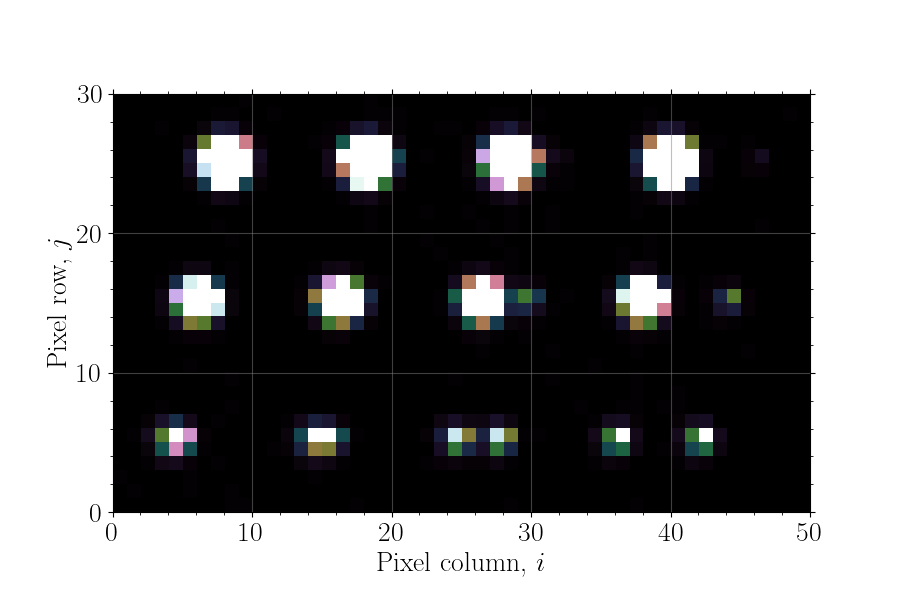

interactive(children=(IntSlider(value=0, description='Image:', layout=Layout(width='70%'), max=9), Output()), …

In [17]:
fig, ax = simfile.showImage(clipPercentile=5, imgScale="clip", fontSize=20, figsize=(9,6),
                            colorMap="cubehelix", colorBar=False, showGrid=True);

---
## Create a GIF of your simulation
---

In [1]:
from platosim.plot import plotSubfieldAnimation

In [ ]:
idir = "/lhome/nicholas/software/workdir/test/output"
filename = idir + "/000000000_Ncam1.1_Q1.hdf5"
plotSubfieldAnimation(filename, outputFileName=idir+"/animation", showStarPositions="PIC", 
                      skipNimages=1000, showMaskOfStarID=1)